### Imports and Configuration

In [1]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from PIL import Image

# Use GPU if available (M1 Mac uses 'mps', Linux uses 'cuda')
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


### Load Ground Truth & Prepare Labels

In [2]:
# Load expert rating summary
df = pd.read_csv("../data/procdata/2_drugSensitivity/expert_rating/expert_rating_summary.csv")

# Filter for consistent ratings (only those without "/")
df_clean = df[~df['rating_merge'].str.contains('/', na=False)].copy()

# Map categories to integers (0-4)
cat_map = {f'cat{i}': i-1 for i in range(1, 6)}
df_clean['label'] = df_clean['rating_merge'].map(cat_map)

# Create full path to images
image_dir = "../data/procdata/2_drugSensitivity/images_clean"
df_clean['file_path'] = df_clean['figure_id'].apply(lambda x: os.path.join(image_dir, f"{x}.png"))

# Split into Train and Test (80/20)
train_df, test_df = train_test_split(df_clean, test_size=0.2, stratify=df_clean['label'], random_state=42)
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

Train size: 1013, Test size: 254


### Calculate weights 

In [3]:
categories = sorted(cat_map.keys(), key=lambda x: cat_map[x])
counts = train_df['rating_merge'].value_counts()
class_counts = [counts.get(cat, 1) for cat in categories]
total_samples = sum(class_counts)
weights = [total_samples / (len(categories) * count) for count in class_counts]
print (f"Class counts: {dict(zip(categories, class_counts))}")
print (f"Class weights: {dict(zip(categories, weights))}")

Class counts: {'cat1': np.int64(244), 'cat2': np.int64(287), 'cat3': np.int64(239), 'cat4': np.int64(170), 'cat5': np.int64(73)}
Class weights: {'cat1': np.float64(0.830327868852459), 'cat2': np.float64(0.7059233449477352), 'cat3': np.float64(0.8476987447698745), 'cat4': np.float64(1.1917647058823528), 'cat5': np.float64(2.7753424657534245)}


### Custom dataset class

In [4]:
class PDXDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['file_path']
        image = Image.open(img_path).convert("RGB")
        label = int(self.dataframe.iloc[idx]['label'])
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Standard ResNet Transforms
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # Zoom in slightly
    transforms.RandomHorizontalFlip(p=0.5), # Mirroring is okay
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Small lighting shifts
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = PDXDataset(train_df, transform=train_transforms)
test_dataset = PDXDataset(test_df, transform=test_transforms)

### Setup dataloader

In [5]:
from torch.utils.data import WeightedRandomSampler

# Get the label for every item in the training set (as integers 0-4)
target_list = torch.tensor(train_df['label'].values)

# Map the class weights to every individual sample in the training set
sample_weights = [weights[t] for t in target_list]

# Create the sampler
sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

# update dataloader to use the sampler for training
train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    sampler=sampler
)

# Test loader (no sampler needed for validation)
test_loader = DataLoader(
    test_dataset, 
    batch_size=32, 
    shuffle=False
)

### Define ResNet-18 model

In [6]:
# Load pre-trained ResNet-18
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Modify the final fully connected layer for 5 categories
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5)

model = model.to(device)

# Convert to tensor and move to device
class_weights = torch.FloatTensor(weights).to(device)

print(f"Dynamic Weights: {weights}")

# Loss and Optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam([
    {'params': model.layer1.parameters(), 'lr': 1e-6},
    {'params': model.layer2.parameters(), 'lr': 1e-6},
    {'params': model.layer3.parameters(), 'lr': 1e-5},
    {'params': model.layer4.parameters(), 'lr': 1e-5},
    {'params': model.fc.parameters(), 'lr': 1e-4} 
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

Dynamic Weights: [np.float64(0.830327868852459), np.float64(0.7059233449477352), np.float64(0.8476987447698745), np.float64(1.1917647058823528), np.float64(2.7753424657534245)]


### Training loop

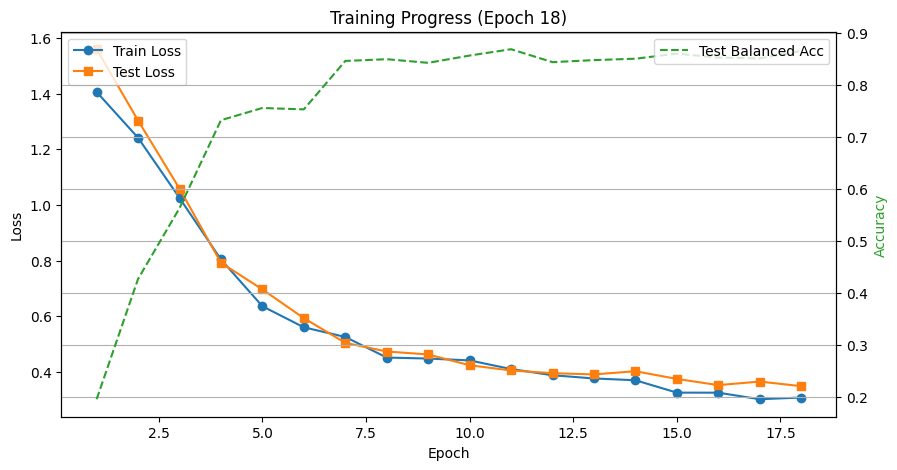

Epoch 18: Train Loss = 0.3081, Test Loss = 0.3489, Test Acc = 0.8657
Early stopping at epoch 18. No improvement (Test Accuracy) for 7 epochs.


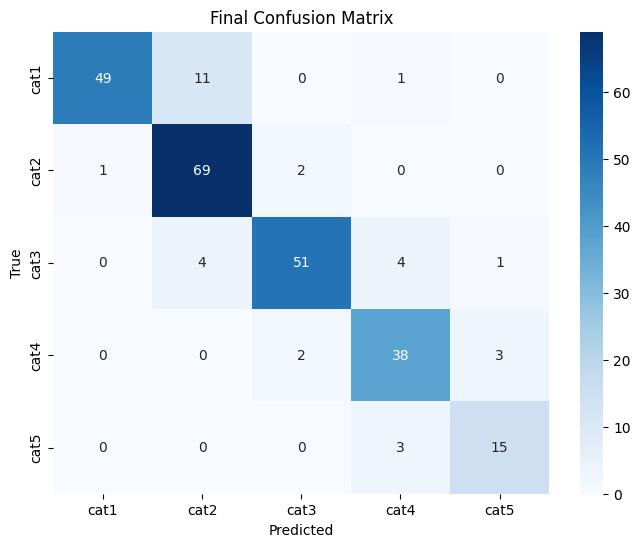

In [7]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import json
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, confusion_matrix
import seaborn as sns

# --- Setup corrections ---
num_epochs = 50
train_losses = []
test_losses = []
test_accs = [] # Separate list for accuracy

best_test_acc = 0.0  # Initialize to zero for accuracy
patience = 7
trigger_times = 0

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * inputs.size(0)
    
    avg_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # --- TESTING/VALIDATION PHASE ---
    model.eval()
    running_test_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item() * inputs.size(0)
            
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    avg_test_loss = running_test_loss / len(test_loader.dataset)
    avg_test_acc = balanced_accuracy_score(all_labels, all_preds)
    
    test_losses.append(avg_test_loss)
    test_accs.append(avg_test_acc)

    # Update Scheduler - Usually stays on Loss
    scheduler.step(avg_test_loss)

    # --- DYNAMIC PLOTTING ---
    clear_output(wait=True)
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot Losses on left axis
    ax1.plot(range(1, epoch + 2), train_losses, label='Train Loss', color='tab:blue', marker='o')
    ax1.plot(range(1, epoch + 2), test_losses, label='Test Loss', color='tab:orange', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color='black')
    ax1.legend(loc='upper left')

    # Create a second y-axis for Accuracy
    ax2 = ax1.twinx()
    ax2.plot(range(1, epoch + 2), test_accs, label='Test Balanced Acc', color='tab:green', linestyle='--')
    ax2.set_ylabel('Accuracy', color='tab:green')
    ax2.legend(loc='upper right')

    plt.title(f'Training Progress (Epoch {epoch+1})')
    plt.grid(True)
    plt.show()

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Test Loss = {avg_test_loss:.4f}, Test Acc = {avg_test_acc:.4f}")

    # CHECKPOINTING LOGIC (Higher Acc is better)
    if avg_test_acc > best_test_acc:
        best_test_acc = avg_test_acc
        torch.save(model.state_dict(), "../data/procdata/2_drugSensitivity/ml_model/resnet18/pdx_resnet18_best.pth")
        print(f"--> New Best Accuracy! {best_test_acc:.4f} (Saved at Epoch {epoch+1})")
        trigger_times = 0
    else:
        trigger_times += 1
        
    # EARLY STOPPING LOGIC
    if trigger_times >= patience:
        print(f"Early stopping at epoch {epoch+1}. No improvement (Test Accuracy) for {patience} epochs.")
        
        # Final Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=categories, yticklabels=categories)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title('Final Confusion Matrix')
        plt.show()
        break

# Save the label mapping for future inference
with open("../data/procdata/2_drugSensitivity/ml_model/resnet18/cat_mapping.json", "w") as f:
    json.dump(cat_map, f)

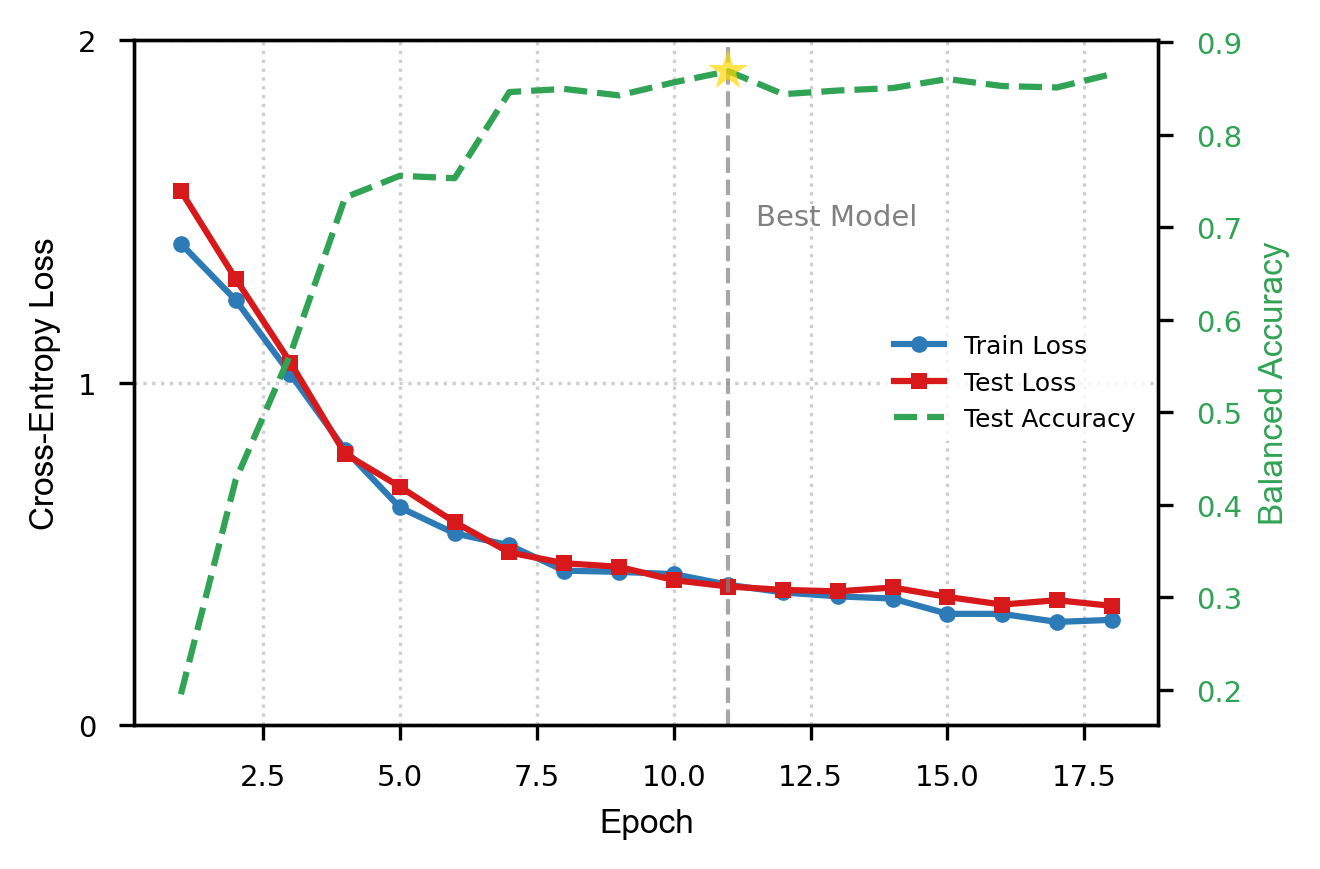

In [ ]:
import matplotlib.pyplot as plt
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Use a professional style base
plt.style.use('seaborn-v0_8-paper') 

def plot_publication_figure(train_losses, test_losses, test_accs):
    # Nature Communications: Single column (89mm) or Double (180mm)
    # 3.5 inches is roughly single column width
    fig, ax1 = plt.subplots(figsize=(4.5, 3), dpi=300) 

    epochs = range(1, len(train_losses) + 1)
    
    # 1. Plot Losses (Left Axis)
    lns1 = ax1.plot(epochs, train_losses, color='#2c7bb6', linewidth=1.5, label='Train Loss', marker='o', markersize=4)
    lns2 = ax1.plot(epochs, test_losses, color='#d7191c', linewidth=1.5, label='Test Loss', marker='s', markersize=4)
    
    ax1.set_xlabel('Epoch', fontsize=8, fontname='Arial')
    ax1.set_ylabel('Cross-Entropy Loss', fontsize=8, fontname='Arial')
    ax1.tick_params(axis='both', labelsize=7)
    
    # 2. Plot Accuracy (Right Axis)
    ax2 = ax1.twinx()
    lns3 = ax2.plot(epochs, test_accs, color='#31a354', linestyle='--', linewidth=1.5, label='Test Accuracy')
    ax2.set_ylabel('Balanced Accuracy', color='#31a354', fontsize=8, fontname='Arial')
    ax2.tick_params(axis='y', labelsize=7, labelcolor='#31a354')

    # Assume 'best_epoch' is the epoch index where you saved the model
    best_epoch = test_accs.index(max(test_accs)) + 1 
    max_acc = max(test_accs)

    # Add a vertical line for the best model
    ax1.axvline(x=best_epoch, color='gray', linestyle='--', linewidth=1, alpha=0.7)

    # Add a star marker or text label
    ax2.plot(best_epoch, max_acc, marker='*', color='gold', markersize=10, 
            markeredgecolor='black', label='Best Model', alpha=0.7)

    # Optional: Annotate the line
    ax1.text(best_epoch + 0.5, ax1.get_ylim()[1] * 0.9, 'Best Model', 
        fontsize=7, color='gray', rotation=0)
    
    # 3. Refined Legend
    # Merge all labels into one legend box
    lns = lns1 + lns2 + lns3
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='center right', fontsize=6, frameon=True, edgecolor='none')

    # 4. Final Touches
    ax1.grid(True, linestyle=':', alpha=0.6)

    ax1.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    max_loss = math.ceil(max(max(train_losses), max(test_losses)))
    ax1.set_ylim(0, max_loss)
    
    plt.tight_layout()
    
    # Save in vector format (PDF/EPS) or high-res TIFF
    # plt.savefig('figure_panel_a.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Call this after your training loop finishes
plot_publication_figure(train_losses, test_losses, test_accs)

### Validate

              precision    recall  f1-score   support

        cat1       0.92      0.93      0.93        61
        cat2       0.90      0.90      0.90        72
        cat3       0.94      0.75      0.83        60
        cat4       0.76      0.95      0.85        43
        cat5       0.94      0.94      0.94        18

    accuracy                           0.89       254
   macro avg       0.89      0.90      0.89       254
weighted avg       0.89      0.89      0.89       254



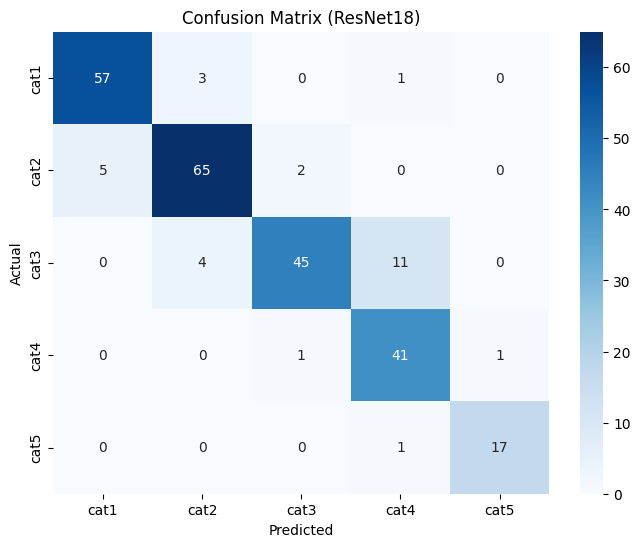

In [17]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load the 'Best' weights from the file before evaluating
model.load_state_dict(torch.load("../data/procdata/2_drugSensitivity/ml_model/resnet18/pdx_resnet18_best.pth"))

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Print Accuracy Report
print(classification_report(all_labels, all_preds, target_names=[f'cat{i}' for i in range(1,6)]))

# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'cat{i}' for i in range(1,6)], 
            yticklabels=[f'cat{i}' for i in range(1,6)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (ResNet18)')
plt.show()

### Prediction for new images

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json

# 1. Recreate the exact model architecture
model = models.resnet18()
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5) # Must match your 5 categories

# 2. Load the saved weights
model.load_state_dict(torch.load("../data/procdata/2_drugSensitivity/ml_model/resnet18/pdx_resnet18_best.pth"))
model.eval() # Set to evaluation mode (important for batchnorm/dropout)

# 3. Define the same preprocessing used in training
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 4. Prediction Function
def predict_pdx_category(image_path):
    img = Image.open(image_path).convert("RGB")
    img_tensor = preprocess(img).unsqueeze(0) # Add batch dimension
    
    with torch.no_grad():
        outputs = model(img_tensor)
        _, predicted = torch.max(outputs, 1)
    
    # Map integer back to cat name (0 -> cat1)
    return f"cat{predicted.item() + 1}"

# Example Usage
result = predict_pdx_category("../data/rawdata/pdxe/test/new_sample.png")
print(f"Predicted Growth Category: {result}")